### Word Embedding

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, f1_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from gensim.models import Word2Vec, FastText

In [167]:
df = pd.read_csv("../data/processed/cleaned_sentiment140.csv")

In [168]:
X = df["Clean_Text"].fillna("").astype(str)
y = df["Label"]

In [169]:
vectorizer = CountVectorizer(max_features=10000)
vectorizertf = TfidfVectorizer(max_features=10000)

In [170]:
test = X.sample()
test

204481    alas i cannot find all the ark photos i was ho...
Name: Clean_Text, dtype: str

In [171]:
test_vec = vectorizer.fit_transform(test)
print(test_vec)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (1, 10)>
  Coords	Values
  (0, 0)	1
  (0, 3)	1
  (0, 4)	1
  (0, 1)	1
  (0, 7)	1
  (0, 2)	1
  (0, 6)	1
  (0, 9)	1
  (0, 5)	1
  (0, 8)	1


In [172]:
test_tf = vectorizertf.fit_transform(test)
print(test_tf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (1, 10)>
  Coords	Values
  (0, 0)	0.31622776601683794
  (0, 3)	0.31622776601683794
  (0, 4)	0.31622776601683794
  (0, 1)	0.31622776601683794
  (0, 7)	0.31622776601683794
  (0, 2)	0.31622776601683794
  (0, 6)	0.31622776601683794
  (0, 9)	0.31622776601683794
  (0, 5)	0.31622776601683794
  (0, 8)	0.31622776601683794


CountVectorizer just count the number of each time word apears in the sentense but TF_IDF apart from counting also measures the importance of each word in that sentence.

In [173]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=11,
                                                    stratify=y,
                                                    shuffle=True)

In [174]:
X_train_tokens = X_train.apply(str.split)

In [175]:
X_train_tokens

1500033    [twice, today., so, i, am, all, good, there., ...
294518     [finished, on, the, bubble., cannot, believe, ...
1169495    [is, making, egg, mayonnaise,, even, though, i...
1145711    [...you, crack, me, up., i, love, that, she, i...
1096575    [you, should, get, up, at, 5am, more, often, t...
                                 ...                        
458563     [i, wish, the, weekend, would, have, losted, l...
1003317       [am, i, seeing, you, at, some, point, tonight]
1001688    [happy, birthday, betty., 18, is, best, age, t...
985126                     [--, lol, yeah, yeah..spam, only]
434660           [we, want, to, move, to, perranporth, sigh]
Name: Clean_Text, Length: 1279999, dtype: object

Word2vec is trained on the list of words, for that it is necessary to tokenize the text.

In [176]:
X_test_tokens = X_test.apply(str.split)

In [177]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

Evaluating Embedding quality

In [178]:
vector = w2v_model.wv["happy"]
sim = w2v_model.wv.most_similar("happy")

In [179]:
print(f"Vector: {vector}")
vector.shape

Vector: [-0.43920955  0.65172553 -0.09829334 -0.17728442  0.2371299  -0.6661672
  1.9920877   2.5698667  -1.340416    1.7172673   0.3028522  -0.18691204
  0.11287397 -1.4934597  -1.3671107   0.39148906  1.1197575  -0.26625165
  1.9309256   2.0766282   0.43823877  0.04492795 -2.0991564  -0.99287045
  2.1984816  -0.6099293   0.7231012  -0.4243285  -0.35440454 -1.2484558
 -0.92132837 -1.3491178  -4.22873     0.7491249   0.43724823 -1.3957682
  2.2699578   0.7262207  -1.1422884  -0.06190953 -2.2085595  -3.4210687
 -2.195291    1.1265318   3.010015   -0.66145325 -2.11753     2.7637606
 -2.4181902   2.5945272   1.2102283  -1.1871685  -0.8207118   2.762601
  0.20494553  0.19073763 -1.2386674   1.766723   -1.2762086  -0.88707906
  1.4322444  -1.9174079  -0.96951115  1.4461552  -2.4138238  -2.5474443
  0.96645963  1.5903177  -0.6639396   0.8722834   1.5760314   0.06714644
  0.15729377  0.0422887  -0.65396476  1.5957983   0.3890312  -0.3986971
  2.2848976  -3.0129905   2.6643174  -2.713342    0.

(100,)

In [180]:
print(f"Similars: {sim}")

Similars: [('happy.', 0.6018370985984802), ('happpy', 0.5813606977462769), ('blessed', 0.5740286707878113), ('&quot;happy', 0.5602794289588928), ("'happy", 0.5575025081634521), ('pleased', 0.5543645620346069), ('happy,', 0.5511016249656677), ('celebrating', 0.5510852932929993), ('thankful', 0.5388022065162659), ('grateful', 0.5208134055137634)]


Based on similar words the embedding model works fine.

In [181]:
def sentense_vectore(tokens, model):

    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)
    

In [182]:
tokens = ["i", "love", "this", "city"]

vec = sentense_vectore(tokens, w2v_model)

print(vec.shape)

(100,)


In [183]:
tokens = ["i", "hate", "this", "country", "for", "all", "bad", "memories"]

vec = sentense_vectore(tokens, w2v_model)

print(vec.shape)

(100,)


In [184]:
X_train_vectors = np.array(
    [sentense_vectore(tokens, w2v_model)
    for tokens in X_train_tokens]
)

In [185]:
X_test_vectors = np.array(
    [sentense_vectore(tokens, w2v_model)
    for tokens in X_test_tokens]
)

In [186]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vectors, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [187]:
y_pred = model.predict(X_test_vectors)

In [188]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate:{error_rate:.2f}")

f1 = f1_score(y_test,y_pred, average="macro")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.75
Precision: 0.75
Recall: 0.75
Error Rate:0.25
F1 Score: 0.75


In [189]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.75      0.75      0.75    160000
           1       0.75      0.75      0.75    160000

    accuracy                           0.75    320000
   macro avg       0.75      0.75      0.75    320000
weighted avg       0.75      0.75      0.75    320000



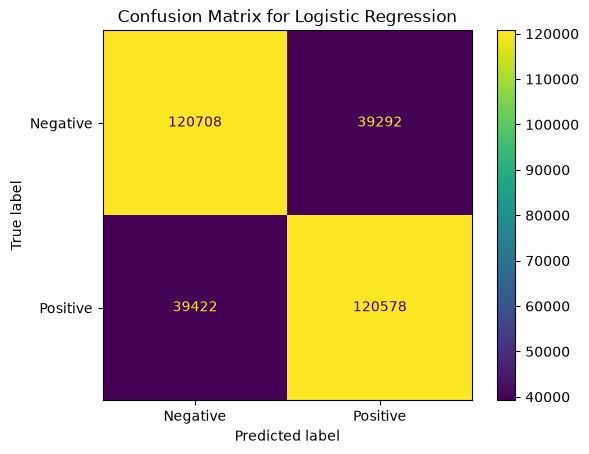

In [190]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

| Model       | Vectorizer | Accuracy | Precision | Recall | F1 |
| ----------- | ---------- | -------- | --------- | ------ | -- |
| Linear SVM  | TF-IDF     |    80    |     80    |   80   | 80 |
| Logistic    | Word2wec   |    75    |     75    |   75   | 75 |

Logistic Regression with Word2wec model get worse result from any models that we evaluate with TF_IDF.

### FastText

In [191]:
ft_train = FastText(
    sentences=X_train_tokens,
    window=5,
    min_count=5,
    workers=4
)

In [192]:
X_train_vectors = np.array(
    [sentense_vectore(tokens, ft_train)
    for tokens in X_train_tokens]
)

In [193]:
X_test_vectors = np.array(
    [sentense_vectore(tokens, ft_train)
     for tokens in X_test_tokens]
)

In [194]:
model.fit(X_train_vectors, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [195]:
y_pred = model.predict(X_test_vectors)

In [196]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate:{error_rate:.2f}")

f1 = f1_score(y_test,y_pred, average="macro")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.75
Precision: 0.75
Recall: 0.75
Error Rate:0.25
F1 Score: 0.75


In [197]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.75      0.75      0.75    160000
           1       0.75      0.75      0.75    160000

    accuracy                           0.75    320000
   macro avg       0.75      0.75      0.75    320000
weighted avg       0.75      0.75      0.75    320000



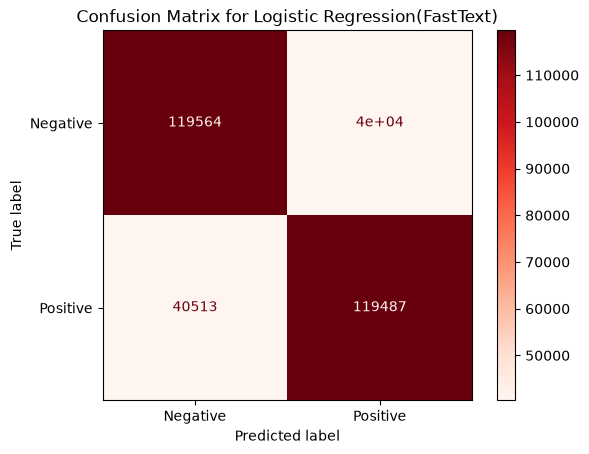

In [198]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Reds")
plt.title("Confusion Matrix for Logistic Regression(FastText)")
plt.show()

| Embedding | Model    | F1 |
| --------- | -------- | -- |
| TF-IDF    | SVM      | 80 |
| Word2Vec  | Logistic | 75 |
| FastText  | Logistic | 75 |


### Visualization

In [199]:
words = [
    "happy", "joy", "love", "great", "awesome",
    "sad", "hate", "bad", "terrible", "awful",
    "movie", "film", "music", "song",
    "good", "best", "worst"
]

In [200]:
vectors = np.array(
    [w2v_model.wv[word]
    for word in words]
)

In [201]:
vectors.shape

(17, 100)

In [202]:
pca = PCA(n_components=2, svd_solver="auto")
reduced_vectors = pca.fit_transform(vectors)

In [203]:
reduced_vectors.shape

(17, 2)

In [204]:
np.array([1, 2, 3])

array([1, 2, 3])

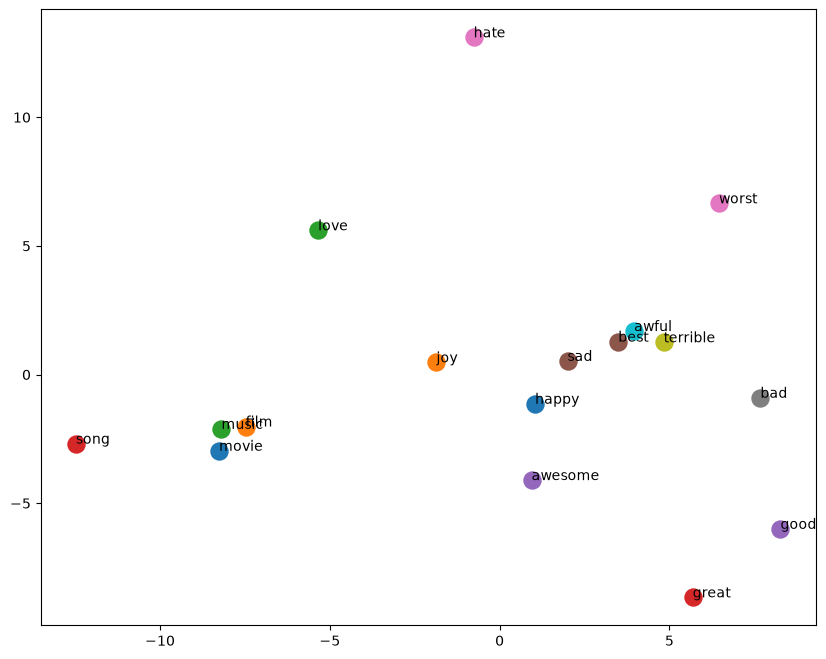

In [206]:
plt.figure(figsize=(10, 8))

for i, word in enumerate(words):
    x = reduced_vectors[i, 0]
    y = reduced_vectors[i, 1]

    plt.scatter(x, y, s=150)
    plt.annotate(word, (x, y))

plt.show()